# Bibliotecas

In [38]:
from obj import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Carregando dados de vigas

In [18]:
# ==================================
# LEITURA DO DATASET
# ==================================

file_path = r'final_df_tempo_limite.xlsx'
full_df = pd.read_excel(file_path)

# Seleciona apenas a primeira linha para análise de teste
df = full_df.head(1)
print(df)


    b_w    h   f_ck      m_rd      m_gk      m_qk       a_s       time
0  0.14  0.3  20000  9.836582  6.323517  0.702613  0.000076  50.621397


# Dados para análise de vida útil

In [19]:
# ==================================
# PARÂMETROS GERAIS DO MODELO
# ==================================

# Número de simulações Monte Carlo
n_simul = 1000

# Tempos de análise (anos)
tempos = np.arange(0, 101, 5)

# Cobrimento das armaduras (mm)
cob = 25

# Módulo de elasticidade do aço (kPa)
e_s = 200E6

# Progressão da carbonatação (mm/ano^0.5)
prog_y = 6

# Coeficientes de Monte Carlo
f_yk_default = 500E3  # kPa


In [20]:
# ============================================
# Modelo preditivo de degradação e confiabilidade
# ============================================

# Inicialização das listas para armazenamento dos resultados globais
results_mr = []   # Momentos resistentes (kN·m)
results_ms = []   # Momentos solicitantes (kN·m)
results_as = []   # Áreas de aço (cm² ou adimensional, conforme definição)
results_g  = []   # Margens de segurança (kN·m)
t_sem_cor  = []   # Tempos sem corrosão (anos)

# Loop principal: percorre cada linha do DataFrame de entrada
for i, row in df.iterrows():

    # -----------------------------
    # Extração dos parâmetros de entrada
    # -----------------------------
    b_w = row['b_w']         # Largura da seção (cm)
    h = row['h']             # Altura da seção (cm)
    f_ck = row['f_ck']       # Resistência característica do concreto (kPa)
    f_yk = 500E3             # Resistência característica do aço (kPa)
    m_gk = row['m_gk']       # Momento de carga permanente (N·cm)
    m_qk = row['m_qk']       # Momento de carga variável (N·cm)
    a_s_initial = row['a_s'] # Área inicial de aço (cm²)

# ==================================
# SIMULAÇÃO MONTE CARLO - DEGRADAÇÃO DA ÁREA DE AÇO
# ==================================

# Inicialização das listas para armazenar resultados
results_mr = []   # Momentos resistentes
results_ms = []   # Momentos solicitantes (m_g + m_q)
results_as = []   # Áreas de aço ao longo do tempo
results_g = []    # Função de estado g

# Loop sobre cada linha do DataFrame
for i, row in df.iterrows():
    # Parâmetros da seção
    b_w = row['b_w']            # largura da seção (cm)
    h = row['h']                # altura da seção (cm)
    f_ck = row['f_ck']          # resistência característica do concreto (kPa)
    f_yk = 500E3                # resistência característica do aço (kPa)
    m_gk = row['m_gk']          # momento devido a cargas permanentes (N·cm)
    m_qk = row['m_qk']          # momento devido a cargas variáveis (N·cm)
    a_s_initial = row['a_s']    # área inicial de aço (cm²)

    # Simulações de Monte Carlo
    for j in range(n_simul):
        m_r_list = []  # momentos resistentes
        a_s_list = []  # áreas de aço
        m_s_list = []  # momentos solicitantes
        g_list = []    # função de estado

        # Amostras das variáveis aleatórias
        f_ck_sample = np.random.normal(1.22 * f_ck, 0.12 * 1.22 * f_ck)
        f_yk_sample = np.random.normal(1.22 * f_yk, 0.05 * 1.22 * f_yk)
        m_gk_sample = np.random.normal(1.06 * m_gk, 0.12 * 1.06 * m_gk)
        relacao_d_h = np.random.uniform(0.8, 0.9)
        i_corr_20 = max(np.random.normal(0.431, 0.259), 1e-5)  # índice de corrosão mínimo positivo

        # Loop sobre os passos de tempo
        for k in tempos:
            # Amostra do momento variável e temperatura ambiente
            m_qk_sample = np.random.gumbel(0.21 * m_qk, 0.21 * 0.76 * m_qk)
            temp = np.random.uniform(20, 30)
            d_barras = 12.5 / 1000  # diâmetro da barra (m)
            n_barras = a_s_initial / (np.pi * d_barras**2 / 4)
            y_carb = prog_y * k**0.5  # profundidade de carbonatação (mm)

            # Cálculo da área de aço degradada
            if y_carb <= cob:
                # Sem corrosão: área original
                a_s_calculada = a_s_initial
                m_rd = momento_limite_armadura_simples(
                    a_s_calculada, b_w, h, relacao_d_h, f_ck_sample, f_yk_sample, e_s
                )
            else:
                # Com corrosão: área reduzida pelo modelo de Azad & Algohi
                t_iniciacao = tempos[0]  # ou tempo de início da corrosão
                m_rd, c_f, d_novo, a_s_calculada = momento_resistente_com_corrosao_azad_algohi(
                    d_barras, n_barras, f_ck_sample, f_yk_sample, e_s,
                    b_w, h, relacao_d_h, i_corr_20, temp, k, t_iniciacao
                )

            # Armazenar resultados
            m_r_list.append(m_rd)
            a_s_list.append(a_s_calculada)
            m_s_list.append(m_gk_sample + m_qk_sample)
            g_list.append(m_rd - (m_gk_sample + m_qk_sample))

        # Adicionar resultados da simulação às listas principais
        results_mr.append(m_r_list)
        results_as.append(a_s_list)
        results_ms.append(m_s_list)
        results_g.append(g_list)

In [21]:
# # ============================================
# # Modelo preditivo de degradação e confiabilidade
# # ============================================

# # Inicialização das listas para armazenamento dos resultados globais
# results_mr = []   # Momentos resistentes (kN·m)
# results_ms = []   # Momentos solicitantes (kN·m)
# results_as = []   # Áreas de aço (cm² ou adimensional, conforme definição)
# results_g  = []   # Margens de segurança (kN·m)
# t_sem_cor  = []   # Tempos sem corrosão (anos)

# # Loop principal: percorre cada linha do DataFrame de entrada
# for i, row in df.iterrows():

#     # -----------------------------
#     # Extração dos parâmetros de entrada
#     # -----------------------------
#     b_w = row['b_w']         # Largura da seção (cm)
#     h = row['h']             # Altura da seção (cm)
#     f_ck = row['f_ck']       # Resistência característica do concreto (kPa)
#     f_yk = 500E3             # Resistência característica do aço (kPa)
#     m_gk = row['m_gk']       # Momento de carga permanente (N·cm)
#     m_qk = row['m_qk']       # Momento de carga variável (N·cm)
#     a_s_initial = row['a_s'] # Área inicial de aço (cm²)

#     # -----------------------------
#     # Simulações de Monte Carlo
#     # -----------------------------
#     for j in range(n_simul):

#         # Inicializa listas temporais para a simulação atual
#         m_r_list = []  # Momentos resistentes
#         a_s_list = []  # Áreas de aço (ou fator de degradação)
#         m_s_list = []  # Momentos solicitantes
#         g_list  = []   # Margens de segurança (m_r - m_s)

#         # -----------------------------
#         # Amostragem aleatória das variáveis
#         # -----------------------------
#         f_ck_sample = np.random.normal(1.22 * f_ck, 0.12 * 1.22 * f_ck)
#         f_yk_sample = np.random.normal(1.22 * f_yk, 0.05 * 1.22 * f_yk)
#         m_gk_sample = np.random.normal(1.06 * m_gk, 0.12 * 1.06 * m_gk)
#         relacao_d_h = np.random.uniform(0.8, 0.9)
#         i_corr_20    = np.random.normal(loc=0.431, scale=0.259)

#         # Corrige valores negativos de corrente de corrosão
#         if i_corr_20 < 0:
#             i_corr_20 = 1E-5

#         # -----------------------------
#         # Loop temporal (análise por tempo de serviço)
#         # -----------------------------
#         for k in tempos:

#             # Amostragem do momento variável (Gumbel)
#             m_qk_sample = np.random.gumbel(0.21 * m_qk, 0.21 * 0.76 * m_qk)

#             # Variação de temperatura ambiente (°C)
#             temp = np.random.uniform(20, 30)

#             # Parâmetros geométricos e físico-químicos
#             d_barras = 12.5 / 1000  # Diâmetro da barra (m)
#             n_barras = a_s_initial / (np.pi * (d_barras ** 2) / 4)
#             y_carb   = prog_y * (k ** 0.5)  # Profundidade de carbonatação (mm)

#             # -----------------------------
#             # Verificação do início da corrosão
#             # -----------------------------
#             if y_carb > cob:
#                 # Período de corrosão ativa
#                 t_dur = k - t_sem_cor[-1]

#                 # Cálculo do momento resistente considerando corrosão
#                 m_rd, c_f, d_corroido, i_corr = momento_resistente_com_corrosao_azad_algohi(
#                     d_barras, n_barras, f_ck_sample, f_yk_sample, e_s,
#                     b_w, h, relacao_d_h, i_corr_20, temp, k, t_sem_cor[-1]
#                 )
#             else:
#                 # Antes do início da corrosão
#                 t_sem_cor.append(k)
#                 m_rd = momento_limite_armadura_simples(
#                     a_s_initial, b_w, h, relacao_d_h, f_ck_sample, f_yk_sample, e_s
#                 )

#             # -----------------------------
#             # Armazenamento dos resultados
#             # -----------------------------
#             m_r_list.append(m_rd)
#             m_s_list.append(m_gk_sample + m_qk_sample)
#             a_s_list.append(1)  # Placeholder — substituir por a_s_degraded se houver
#             g_list.append(m_rd - (m_gk_sample + m_qk_sample))

#         # -----------------------------
#         # Resultados da simulação completa
#         # -----------------------------
#         results_mr.append(m_r_list)
#         results_ms.append(m_s_list)
#         results_as.append(a_s_list)
#         results_g.append(g_list)


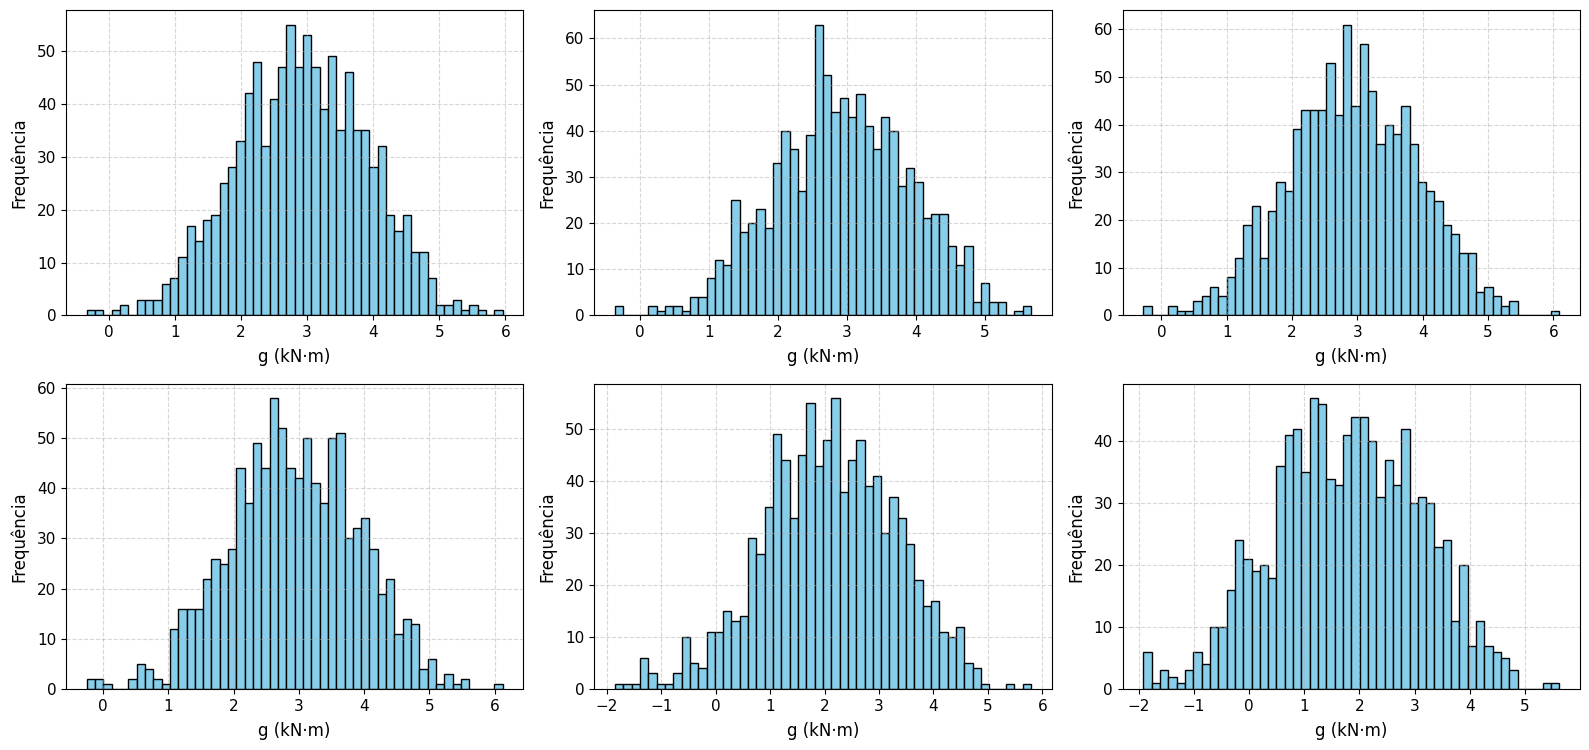

In [22]:
# ================================================================
# Análise estatística e visualização dos resultados da simulação
# ================================================================

# Lista com os tempos correspondentes aos índices de cada valor em g_list
times = [0, 20, 40, 60, 80, 100]

# Criação de um dicionário para armazenar os valores de g (m_r - m_gk - m_qk)
# separados por tempo de análise
t_dict = {time: [] for time in times}

# Itera sobre cada simulação e organiza os resultados por tempo
for g_list in results_g:
    for idx, time in enumerate(times):
        t_dict[time].append(g_list[idx])

# Criação de listas separadas para cada tempo (facilita manipulação posterior)
t_0   = t_dict[0]
t_20  = t_dict[20]
t_40  = t_dict[40]
t_60  = t_dict[60]
t_80  = t_dict[80]
t_100 = t_dict[100]

# Agrupamento das listas principais para iteração conjunta nos gráficos
t_lists = [t_0, t_20, t_40, t_60, t_80, t_100]

# ================================================================
# Geração dos histogramas de distribuição para cada tempo analisado
# ================================================================

# Criação da figura e dos eixos para 6 subplots (2 linhas x 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Ajuste do espaçamento entre subplots
plt.subplots_adjust(wspace=0.25, hspace=0.3)

# Loop de plotagem: um histograma para cada tempo de exposição
for idx, (t_values, time) in enumerate(zip(t_lists, times)):
    ax = axes[idx // 3, idx % 3]  # Define a posição do subplot (linha, coluna)

    # Histograma
    ax.hist(t_values, bins=50, color='skyblue', edgecolor='black')

    # Ajuste do tamanho e fonte dos eixos
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.tick_params(axis='both', which='minor', labelsize=9)

    # Rótulos dos eixos com fonte ajustada
    ax.set_xlabel('g (kN·m)', fontsize=12, labelpad=6)
    ax.set_ylabel('Frequência', fontsize=12, labelpad=6)

    # Grade sutil para melhor leitura
    ax.grid(True, linestyle='--', alpha=0.5)

# Layout final e exibição
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [23]:
# # ================================================================
# # Generation of distribution histograms for each analyzed time
# # ================================================================

# # Create the figure and axes for 6 subplots (2 rows x 3 columns)
# fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# # Adjust spacing between subplots
# plt.subplots_adjust(wspace=0.25, hspace=0.3)

# # Plotting loop: one histogram for each exposure time
# for idx, (t_values, time) in enumerate(zip(t_lists, times)):
#     ax = axes[idx // 3, idx % 3]  # Defines subplot position (row, column)

#     # Histogram
#     ax.hist(t_values, bins=50, color='skyblue', edgecolor='black')

#     # Axis size and font adjustments
#     ax.tick_params(axis='both', which='major', labelsize=11)
#     ax.tick_params(axis='both', which='minor', labelsize=9)

#     # Axis labels with adjusted font
#     ax.set_xlabel('g (kN·m)', fontsize=12, labelpad=6)
#     ax.set_ylabel('Frequency', fontsize=12, labelpad=6)

#     # Subtle grid for better readability
#     ax.grid(True, linestyle='--', alpha=0.5)

# # Final layout and display
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()


In [35]:
# ===============================
# CONFIGURAÇÕES DE TAMANHO E ESTILO DO GRÁFICO
# ===============================
config_grafico = {
    "figsize": (8, 5),        # Tamanho da figura (largura x altura)
    "fonte_label": 13,        # Tamanho da fonte dos labels
    "fonte_tick": 11,         # Tamanho dos números nos eixos
    "line_width": 1.5,        # Espessura das linhas
    "alpha": 0.3,             # Transparência das curvas
    "marker_size": 3,         # Tamanho dos marcadores
    "dpi": 600,               # Resolução para salvar
    "cor": "gray",            # Cor das curvas
    "cor_vertical": "red",    # Cor das linhas verticais
    "linestyle": "-",         # Estilo da linha ('-', '--', '-.', ':')
}


GRÁFICO DO MOMENTO RESISTENTE

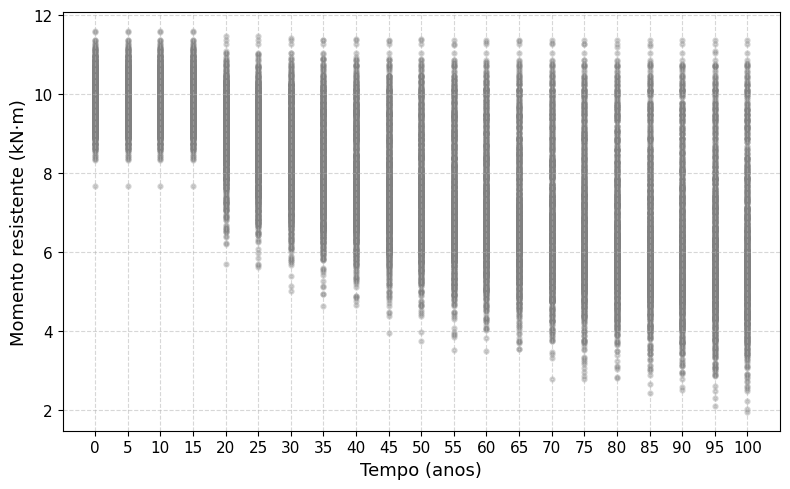

In [25]:
# ===============================
# PLOTAGEM DAS CURVAS DE MOMENTO RESISTENTE
# ===============================
plt.figure(figsize=config_grafico["figsize"])

for m_r_curve in results_mr:
    plt.scatter(
        tempos, 
        m_r_curve,
        marker='o',
        linestyle='-',
        color=config_grafico["cor"],
        alpha=config_grafico["alpha"],
        s=config_grafico["marker_size"]**2,  # Matplotlib usa área para o tamanho do scatter
        linewidth=config_grafico["line_width"]
    )

# Configuração dos eixos com títulos
plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
plt.ylabel("Momento resistente (kN·m)", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', which='major', labelsize=config_grafico["fonte_tick"])

# Grade e layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()

# Salvamento em alta resolução
plt.savefig('moment_cap_curves.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# Exibir o gráfico
plt.show()

In [26]:
# # ===============================
# # PLOTTING OF RESISTING MOMENT CURVES
# # ===============================
# plt.figure(figsize=config_grafico["figsize"])

# for m_r_curve in results_mr:
#     plt.scatter(
#         tempos, 
#         m_r_curve,
#         marker='o',
#         linestyle='-',
#         color=config_grafico["cor"],
#         alpha=config_grafico["alpha"],
#         s=config_grafico["marker_size"]**2,  # Matplotlib uses area for scatter size
#         linewidth=config_grafico["line_width"]
#     )

# # Axis configuration with titles
# plt.xlabel("Time (years)", fontsize=config_grafico["fonte_label"])
# plt.ylabel("Resisting moment (kN·m)", fontsize=config_grafico["fonte_label"])
# plt.tick_params(axis='both', which='major', labelsize=config_grafico["fonte_tick"])

# # Grid and layout
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.xticks(tempos)
# plt.tight_layout()

# # Save in high resolution
# plt.savefig('moment_cap_curves.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# # Display the plot
# plt.show()


GRÁFICO DO MOMENTO SOLICITANTE

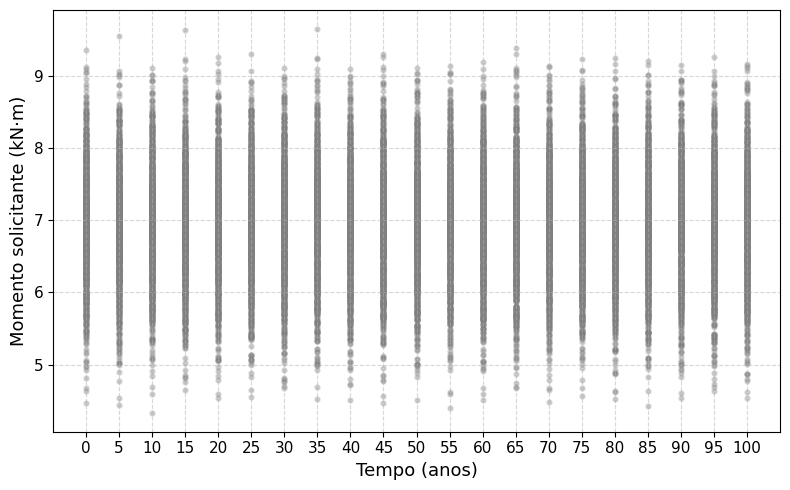

In [27]:
# ===============================
# PLOTAGEM DAS CURVAS DE MOMENTO SOLICITANTE
# ===============================
plt.figure(figsize=config_grafico["figsize"])

for m_s_curve in results_ms:
    plt.scatter(
        tempos, 
        m_s_curve,
        marker='o',
        linestyle='-',
        color=config_grafico["cor"],
        alpha=config_grafico["alpha"],
        s=config_grafico["marker_size"]**2,  # Matplotlib usa área para o tamanho do scatter
        linewidth=config_grafico["line_width"]
    )

# Configuração dos eixos com títulos
plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
plt.ylabel("Momento solicitante (kN·m)", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', which='major', labelsize=config_grafico["fonte_tick"])

# Grade e layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()

# Salvamento em alta resolução
plt.savefig('curvas_momento_solicitante.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# Exibir o gráfico
plt.show()

In [28]:
# # ===============================
# # PLOTTING OF APPLIED MOMENT CURVES
# # ===============================
# plt.figure(figsize=config_grafico["figsize"])

# for m_s_curve in results_ms:
#     plt.scatter(
#         tempos, 
#         m_s_curve,
#         marker='o',
#         linestyle='-',
#         color=config_grafico["cor"],
#         alpha=config_grafico["alpha"],
#         s=config_grafico["marker_size"]**2,  # Matplotlib uses area for scatter size
#         linewidth=config_grafico["line_width"]
#     )

# # Axis configuration with titles
# plt.xlabel("Time (years)", fontsize=config_grafico["fonte_label"])
# plt.ylabel("Applied moment (kN·m)", fontsize=config_grafico["fonte_label"])
# plt.tick_params(axis='both', which='major', labelsize=config_grafico["fonte_tick"])

# # Grid and layout
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.xticks(tempos)
# plt.tight_layout()

# # Save in high resolution
# plt.savefig('applied_moment_curves.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# # Display the plot
# plt.show()


FUNÇÃO DE ESTADO g

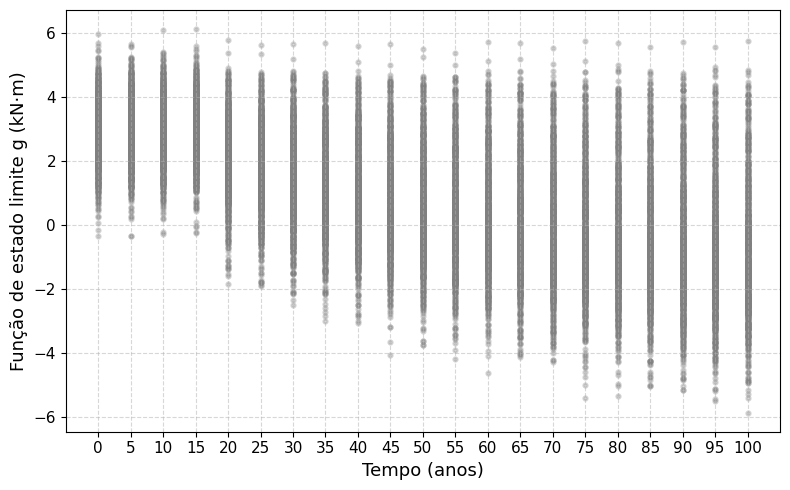

In [29]:
# ===============================
# PLOTAGEM DAS CURVAS DA FUNÇÃO ESTADO LIMITE (g)
# ===============================
plt.figure(figsize=config_grafico["figsize"])

for g_curve in results_g:
    plt.scatter(
        tempos,
        g_curve,
        marker='o',
        linestyle='-',
        color=config_grafico["cor"],
        alpha=config_grafico["alpha"],
        s=config_grafico["marker_size"]**2,
        linewidth=config_grafico["line_width"]
    )

# Configuração dos eixos com títulos
plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
plt.ylabel("Função de estado limite g (kN·m)", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', which='major', labelsize=config_grafico["fonte_tick"])

# Grade e layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()

# Salvamento em alta resolução
plt.savefig('momentos_estado_limite.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# Exibir o gráfico
plt.show()

In [30]:
# # ===============================
# # PLOTTING OF LIMIT STATE FUNCTION (g) CURVES
# # ===============================
# plt.figure(figsize=config_grafico["figsize"])

# for g_curve in results_g:
#     plt.scatter(
#         tempos,
#         g_curve,
#         marker='o',
#         linestyle='-',
#         color=config_grafico["cor"],
#         alpha=config_grafico["alpha"],
#         s=config_grafico["marker_size"]**2,
#         linewidth=config_grafico["line_width"]
#     )

# # Axis configuration with titles
# plt.xlabel("Time (years)", fontsize=config_grafico["fonte_label"])
# plt.ylabel("Limit state function g (kN·m)", fontsize=config_grafico["fonte_label"])
# plt.tick_params(axis='both', which='major', labelsize=config_grafico["fonte_tick"])

# # Grid and layout
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.xticks(tempos)
# plt.tight_layout()

# # High-resolution saving
# plt.savefig('momentos_estado_limite.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# # Display the plot
# plt.show()


Total de curvas geradas: 1000
Total de curvas filtradas: 745


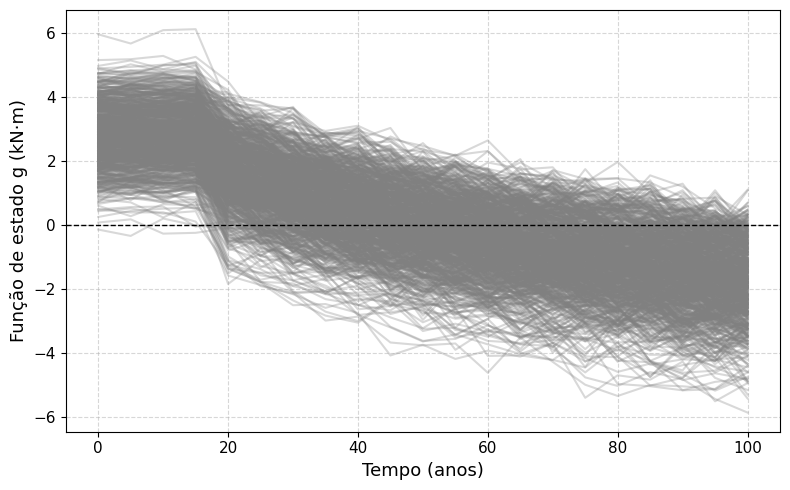

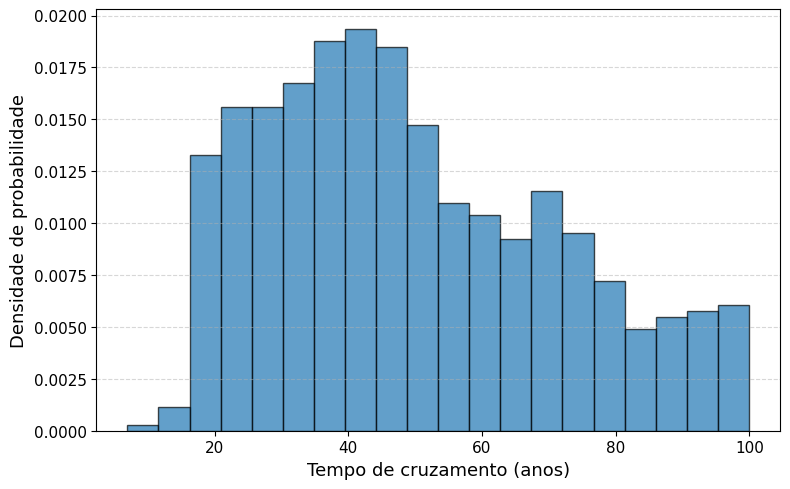

In [36]:
# ==================================
# FILTRAGEM DAS CURVAS QUE CRUZAM g = 0
# ==================================
curvas_filtradas = []
tempos_cruzamento = []

for g in results_g:
    if any(x < 0 for x in g):  # Apenas curvas que cruzam o zero
        for i in range(1, len(g)):
            if g[i-1] > 0 and g[i] <= 0:
                # Interpolação linear para encontrar o tempo exato de cruzamento
                t1, t2 = tempos[i-1], tempos[i]
                g1, g2 = g[i-1], g[i]
                tempo_cruz = t1 - g1 * (t2 - t1) / (g2 - g1)
                tempos_cruzamento.append(tempo_cruz)
                curvas_filtradas.append(g)
                break

curvas_filtradas = np.array(curvas_filtradas)

# # Converte para numpy array apenas se houver curvas filtradas
# if curvas_filtradas:
#     curvas_filtradas = np.array(curvas_filtradas)
# else:
#     curvas_filtradas = np.empty((0, len(tempos)))  # cria array vazio compatível

# ==================================
# SALVAMENTO EM EXCEL
# ==================================
with pd.ExcelWriter("resultados_curvas.xlsx") as writer:
    # Aba 1: Tempos de cruzamento
    pd.DataFrame({"Tempo_de_cruzamento_anos": tempos_cruzamento}).to_excel(
        writer, sheet_name="Tempos_de_Cruzamento", index=False
    )
    
    # Aba 2: Curvas filtradas (cada coluna = uma curva) se houver curvas
    if curvas_filtradas.size > 0:
        df_curvas = pd.DataFrame(
            curvas_filtradas.T,
            columns=[f"Curva_{i+1}" for i in range(curvas_filtradas.shape[0])]
        )
        df_curvas.to_excel(writer, sheet_name="Curvas_Filtradas", index=False)

# ==================================
# INFORMAÇÕES GERAIS
# ==================================
print(f"Total de curvas geradas: {len(results_g)}")
print(f"Total de curvas filtradas: {len(curvas_filtradas)}")

# ==================================
# GRÁFICO DAS CURVAS FILTRADAS
# ==================================
if curvas_filtradas.size > 0:
    plt.figure(figsize=config_grafico["figsize"])
    for g in curvas_filtradas:
        plt.plot(
            tempos, g,
            color=config_grafico["cor"],
            alpha=config_grafico["alpha"],
            linestyle=config_grafico["linestyle"]
        )
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
    plt.ylabel("Função de estado g (kN·m)", fontsize=config_grafico["fonte_label"])
    plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("curvas_filtradas.png", dpi=config_grafico["dpi"], bbox_inches="tight")
    plt.show()
else:
    print("Não há curvas que cruzam g = 0 para plotar.")

# ==================================
# HISTOGRAMA DOS TEMPOS DE CRUZAMENTO
# ==================================
if tempos_cruzamento:
    plt.figure(figsize=config_grafico["figsize"])
    plt.hist(tempos_cruzamento, bins=20, edgecolor="black", alpha=0.7, density=True)
    plt.xlabel("Tempo de cruzamento (anos)", fontsize=config_grafico["fonte_label"])
    plt.ylabel("Densidade de probabilidade", fontsize=config_grafico["fonte_label"])
    plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("histograma_tempos_cruzamento.png", dpi=config_grafico["dpi"], bbox_inches="tight")
    plt.show()
else:
    print("Não há tempos de cruzamento para gerar histograma.")




In [ ]:
# # ==================================
# # PLOT OF FILTERED CURVES
# # ==================================
# if curvas_filtradas.size > 0:
#     plt.figure(figsize=config_grafico["figsize"])
#     for g in curvas_filtradas:
#         plt.plot(
#             tempos, g,
#             color=config_grafico["cor"],
#             alpha=config_grafico["alpha"],
#             linestyle=config_grafico["line_style"]
#         )
#     plt.axhline(0, color='k', linestyle='--', linewidth=1)
#     plt.xlabel("Time (years)", fontsize=config_grafico["fonte_label"])
#     plt.ylabel("Limit state function g (kN·m)", fontsize=config_grafico["fonte_label"])
#     plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
#     plt.grid(True, linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.savefig("curvas_filtradas.png", dpi=config_grafico["dpi"], bbox_inches="tight")
#     plt.show()
# else:
#     print("No curves crossing g = 0 to plot.")

# # ==================================
# # HISTOGRAM OF CROSSING TIMES
# # ==================================
# if tempos_cruzamento:
#     plt.figure(figsize=config_grafico["figsize"])
#     plt.hist(tempos_cruzamento, bins=20, edgecolor="black", alpha=0.7, density=True)
#     plt.xlabel("Crossing time (years)", fontsize=config_grafico["fonte_label"])
#     plt.ylabel("Probability density", fontsize=config_grafico["fonte_label"])
#     plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
#     plt.grid(axis="y", linestyle="--", alpha=0.5)
#     plt.tight_layout()
#     plt.savefig("histograma_tempos_cruzamento.png", dpi=config_grafico["dpi"], bbox_inches="tight")
#     plt.show()
# else:
#     print("No crossing times to generate histogram.")


No curves crossing g = 0 to plot.
No crossing times to generate histogram.



FUNÇÃO DE ESTADO g: CURVAS E DISTRIBUIÇÃO EM ANO ESPECÍFICO



Ano de análise: 35 anos
Total de curvas simuladas: 1000
Total de falhas (g < 0): 204
Probabilidade de falha (p_f): 0.204000
Índice de confiabilidade (β): 0.827


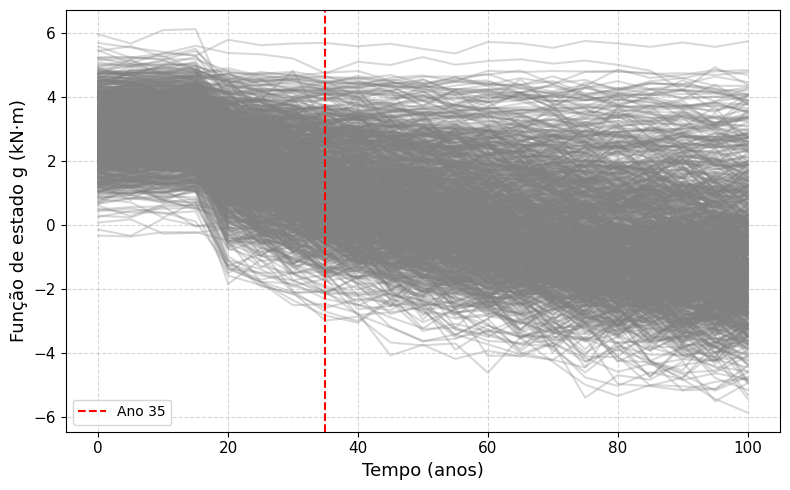

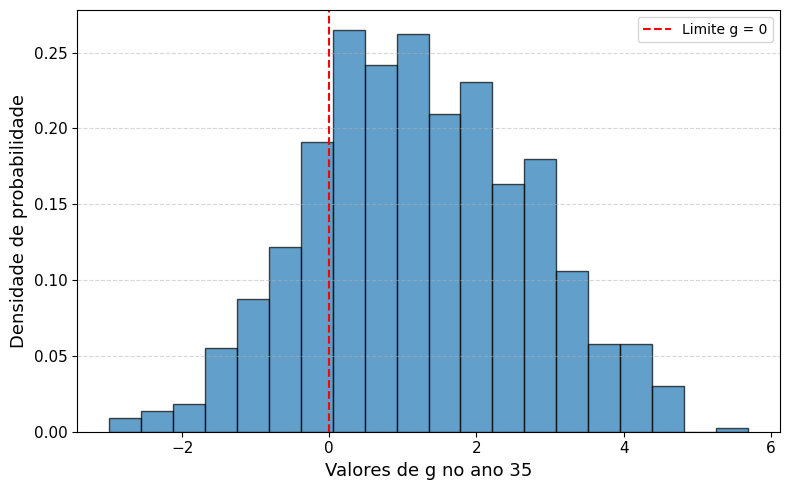

In [39]:
# ==================================
# DADOS
# ==================================
tempos_analise = tempos.copy()
curvas = results_g.copy()

if len(curvas) == 0:
    raise ValueError("Não há curvas em 'results_g'. Verifique a simulação antes de plotar.")

# Entrada do usuário
ano_escolhido = 35
if ano_escolhido < 0 or ano_escolhido > 100:
    raise ValueError("O ano deve estar entre 0 e 100.")

# Calcular valores de g no ano escolhido (interpolação linear)
g_no_ano = [np.interp(ano_escolhido, tempos_analise, g) for g in curvas]

# ==================================
# ANÁLISE ESTATÍSTICA
# ==================================
total_curvas = len(g_no_ano)
falhas = np.sum(np.array(g_no_ano) < 0)
pf = falhas / total_curvas
if pf > 0:
    beta = -np.sqrt(2) * scipy.special.erfinv(2 * pf - 1)
else:
    beta = np.inf  # Nenhuma falha observada

# Exibir resultados
print("="*40)
print(f"Ano de análise: {ano_escolhido} anos")
print(f"Total de curvas simuladas: {total_curvas}")
print(f"Total de falhas (g < 0): {falhas}")
print(f"Probabilidade de falha (p_f): {pf:.6f}")
print(f"Índice de confiabilidade (β): {beta:.3f}")
print("="*40)

# ==================================
# GRÁFICO DAS CURVAS COM LINHA VERTICAL
# ==================================
plt.figure(figsize=config_grafico["figsize"])
for g in curvas:
    plt.plot(tempos_analise, g, color=config_grafico["cor"],
             alpha=config_grafico["alpha"],
             linestyle=config_grafico.get("linestyle", "-"))
plt.axvline(x=ano_escolhido, color=config_grafico["cor_vertical"],
            linestyle='--', linewidth=1.5, label=f"Ano {ano_escolhido}")
plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
plt.ylabel("Função de estado g (kN·m)", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==================================
# HISTOGRAMA DOS VALORES DE g NO ANO ESCOLHIDO
# ==================================
plt.figure(figsize=config_grafico["figsize"])
plt.hist(g_no_ano, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label="Limite g = 0")
plt.xlabel(f"Valores de g no ano {ano_escolhido}", fontsize=config_grafico["fonte_label"])
plt.ylabel("Densidade de probabilidade", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



Ano de análise: 35 anos
Total de curvas simuladas: 1000
Total de falhas (g < 0): 204
Probabilidade de falha (p_f): 0.204000
Índice de confiabilidade (β): 0.827


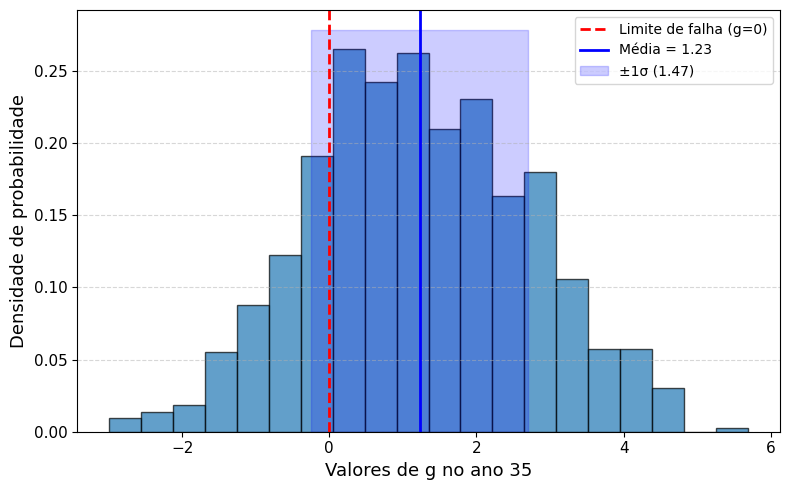

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# ANÁLISE ESTATÍSTICA PARA O ANO ESCOLHIDO
# ==================================
g_no_ano = np.array([np.interp(ano_escolhido, tempos_analise, g) for g in curvas])

total_curvas = len(curvas)
falhas = np.sum(g_no_ano < 0)
p_f = falhas / total_curvas
media_g = np.mean(g_no_ano)
std_g = np.std(g_no_ano)

print("========================================")
print(f"Ano de análise: {ano_escolhido} anos")
print(f"Total de curvas simuladas: {total_curvas}")
print(f"Total de falhas (g < 0): {falhas}")
print(f"Probabilidade de falha (p_f): {p_f:.6f}")

from scipy.stats import norm
beta = -norm.ppf(p_f)  # índice de confiabilidade
print(f"Índice de confiabilidade (β): {beta:.3f}")
print("========================================")

# ==================================
# HISTOGRAMA COM LINHAS DE MÉDIA, DESVIO E LIMITE
# ==================================
plt.figure(figsize=config_grafico["figsize"])
plt.hist(g_no_ano, bins=20, edgecolor='black', alpha=0.7, density=True)

# Limite de falha g = 0
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Limite de falha (g=0)')

# Média
plt.axvline(media_g, color='blue', linestyle='-', linewidth=2, label=f"Média = {media_g:.2f}")

# Sombreamento do desvio padrão
plt.fill_betweenx(
    y=[0, plt.gca().get_ylim()[1]],
    x1=media_g - std_g,
    x2=media_g + std_g,
    color='blue',
    alpha=0.2,
    label=f"±1σ ({std_g:.2f})"
)

plt.xlabel(f"Valores de g no ano {ano_escolhido}", fontsize=config_grafico["fonte_label"])
plt.ylabel("Densidade de probabilidade", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# # ==================================
# # PLOT OF CURVES WITH VERTICAL LINE
# # ==================================
# plt.figure(figsize=config_grafico["figsize"])
# for g in curvas:
#     plt.plot(tempos_analise, g, color=config_grafico["cor"], alpha=config_grafico["alpha"])
# plt.axvline(x=ano_escolhido, color=config_grafico["cor_vertical"], linestyle='--', label=f"Year {ano_escolhido}")
# plt.xlabel("Time (years)", fontsize=config_grafico["fonte_label"])
# plt.ylabel("Limit state function g (kN·m)", fontsize=config_grafico["fonte_label"])
# plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

# # ==================================
# # HISTOGRAM OF g VALUES AT THE SELECTED YEAR
# # ==================================
# plt.figure(figsize=config_grafico["figsize"])
# plt.hist(g_no_ano, bins=20, edgecolor='black', alpha=0.7, density=True)
# plt.xlabel(f"g values at year {ano_escolhido}", fontsize=config_grafico["fonte_label"])
# plt.ylabel("Probability density", fontsize=config_grafico["fonte_label"])
# plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()


GRÁFICO DE DEGRADAÇÃO DO AÇO

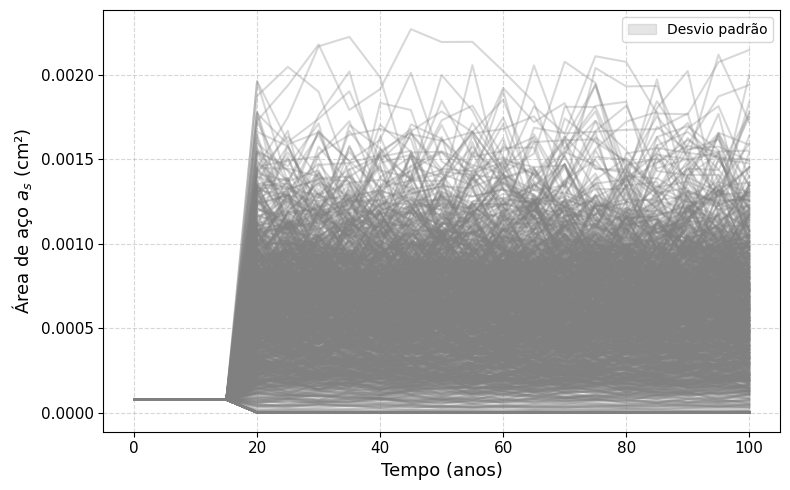

In [34]:
# ==================================
# DADOS
# ==================================
tempos_analise = tempos.copy()
areas_aco = np.array(results_as)  # Converter lista para array (simulações x tempos)

# Calcular média e desvio padrão da área de aço em cada passo de tempo
media_as = np.mean(areas_aco, axis=0)
std_as = np.std(areas_aco, axis=0)

# ==================================
# PLOTAGEM
# ==================================
plt.figure(figsize=config_grafico["figsize"])

# Curvas individuais
for a_s_curve in areas_aco:
    plt.plot(tempos_analise, a_s_curve, color=config_grafico["cor"], alpha=config_grafico["alpha"])

# Sombra de desvio padrão
plt.fill_between(
    tempos_analise,
    media_as - std_as,
    media_as + std_as,
    color=config_grafico["cor"],
    alpha=0.2,
    label="Desvio padrão"
)

# Formatação
plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
plt.ylabel("Área de aço $a_s$ (cm²)", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar gráfico
plt.show()



In [ ]:
# # ==================================
# # PLOTTING
# # ==================================
# plt.figure(figsize=config_grafico["figsize"])

# # Individual curves
# for a_s_curve in areas_aco:
#     plt.plot(tempos_analise, a_s_curve, color=config_grafico["cor"], alpha=config_grafico["alpha"])

# # Standard deviation shading
# plt.fill_between(
#     tempos_analise,
#     media_as - std_as,
#     media_as + std_as,
#     color=config_grafico["cor"],
#     alpha=0.2,
#     label="Standard deviation"
# )

# # Formatting
# plt.xlabel("Time (years)", fontsize=config_grafico["fonte_label"])
# plt.ylabel("Steel area $a_s$ (cm²)", fontsize=config_grafico["fonte_label"])
# plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()

# # Show plot
# plt.show()
